# Stage 3 — Exploratory Data Analysis
### Maven Fuzzy Factory (Online Toy Store) · Tier A pipeline

> **Purpose.** Hypothesis-driven EDA — **one exhibit per branch** of the Stage 0 issue tree (Acquisition → Conversion → Monetization → Leakage). Every chart has an **action title** (states the insight) and a **So What** (the business implication). Exhibits are styled via [`src/mck_style.py`](../src/mck_style.py) and exported to `reports/figures/` for reuse in the Stage 7 report.

Reads the `data/processed/` Parquet tables from Stage 2. See [`DOCS/STRUCTURE.md`](../DOCS/STRUCTURE.md) §3 and [`DOCS/DESIGN.md`](../DOCS/DESIGN.md).

**Issue tree (from the plan):**
- **A. Acquisition** — which traffic converts (channel, device, new-vs-repeat)?
- **B. Conversion** — where does the funnel leak; which landing page wins; is it improving?
- **C. Monetization** — product mix & margin; cross-sell.
- **D. Leakage** — refund rate by product and over time.

> **Discipline:** these are *diagnostic* (associational) findings. Any recommendation that implies an intervention ("switch all traffic to lander-5") is flagged for Path C, not asserted here.

## 0. Setup & load processed data

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import mck_style, visualization as viz

C = mck_style.apply()  # apply McKinsey rcParams; returns palette dict

P = PROJECT_ROOT / "data" / "processed"
ss = pd.read_parquet(P / "session_summary.parquet")
orders = pd.read_parquet(P / "orders.parquet")
order_items = pd.read_parquet(P / "order_items.parquet")
refunds = pd.read_parquet(P / "order_item_refunds.parquet")
products = pd.read_parquet(P / "products.parquet")
pageviews = pd.read_parquet(P / "website_pageviews.parquet")

N_SESSIONS = len(ss)
print(f"{N_SESSIONS:,} sessions | {len(orders):,} orders | overall conversion {ss['is_converted'].mean():.2%}")

472,871 sessions | 32,313 orders | overall conversion 6.83%


In [2]:
def conv_by(col, source=ss, min_n=0):
    """Conversion rate + volume by a categorical column."""
    g = (source.groupby(col, observed=True)
         .agg(sessions=("is_converted", "size"), conv=("is_converted", "mean"))
         .query("sessions >= @min_n"))
    g["conv_pct"] = g["conv"] * 100
    return g

SRC = "Source: Maven Fuzzy Factory, 2012-03 to 2015-03. Analysis: session_summary (n=472,871)."

---
## Part A — Acquisition
*MECE branch: which traffic should we get more of?*

### Exhibit A1 — Device is the single biggest conversion lever

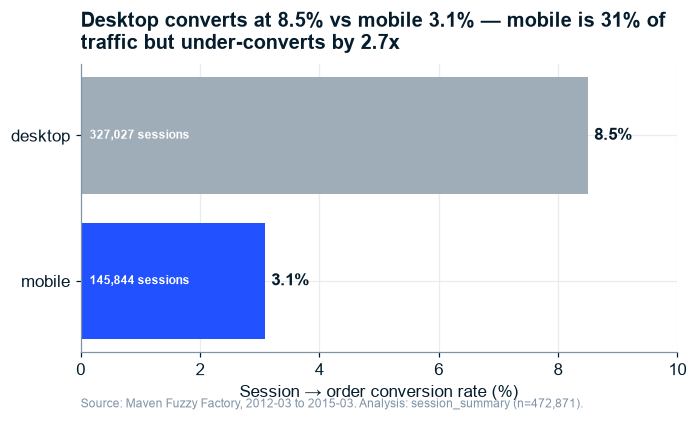

In [3]:
d = conv_by("device_type").sort_values("conv_pct")
fig, ax = plt.subplots(figsize=(7, 3.4))
colors = mck_style.highlight_colors(d.index, winner="mobile")  # mobile = the opportunity
ax.barh(d.index, d["conv_pct"], color=colors)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=4, fontweight="bold")
ax.set_title("Desktop converts at 8.5% vs mobile 3.1% \u2014 mobile is 31% of\ntraffic but under-converts by 2.7x")
ax.set_xlabel("Session \u2192 order conversion rate (%)")
ax.set_xlim(0, 10)
for i, (n, row) in enumerate(d.iterrows()):
    ax.annotate(f"{row['sessions']:,.0f} sessions", (0.15, i), va="center", ha="left", color="white", fontsize=8, fontweight="bold")
viz.add_source(ax, SRC)
viz.save_exhibit(fig, "A1_conversion_by_device"); plt.show()

**So What:** Mobile is nearly a third of all traffic yet converts at *one-third* the desktop rate. Closing even part of this gap is the largest single conversion opportunity in the funnel. **Implication:** prioritise a mobile-experience diagnosis (the landing-page test in Part B is the natural lever). *Caveat: associational — device also correlates with channel and intent.*

### Exhibit A2 — Paid search drives volume but converts below untagged traffic

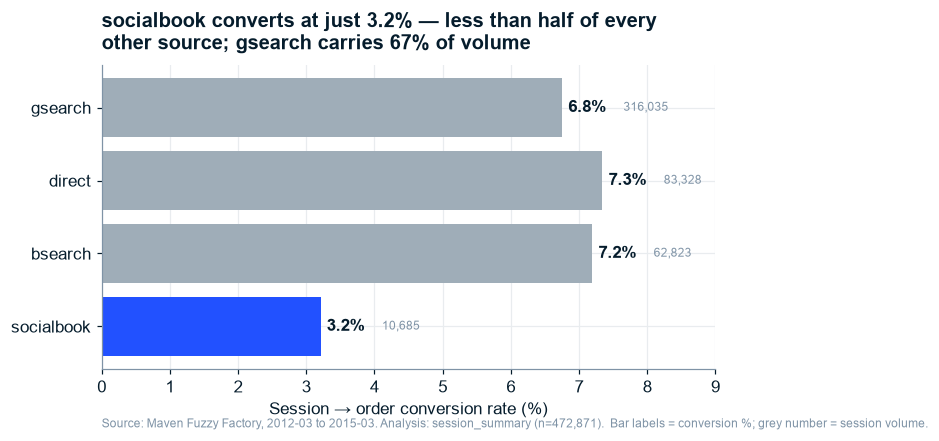

In [4]:
d = conv_by("utm_source").sort_values("sessions", ascending=True)
fig, ax = plt.subplots(figsize=(7.2, 3.6))
colors = mck_style.highlight_colors(d.index, winner="socialbook")  # worst converter = flag
ax.barh(d.index, d["conv_pct"], color=colors)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=4, fontweight="bold")
ax.set_title("socialbook converts at just 3.2% \u2014 less than half of every\nother source; gsearch carries 67% of volume")
ax.set_xlabel("Session \u2192 order conversion rate (%)")
ax.set_xlim(0, 9)
for i, (n, row) in enumerate(d.iterrows()):
    ax.annotate(f"{row['sessions']:,.0f}", (row['conv_pct'] + 0.9, i), va="center", ha="left", color=mck_style.SLATE, fontsize=8)
viz.add_source(ax, SRC + "  Bar labels = conversion %; grey number = session volume.")
viz.save_exhibit(fig, "A2_conversion_by_source"); plt.show()

**So What:** `gsearch` dominates volume (316k sessions) at a middling 6.75%, while `socialbook` (10.7k) converts at 3.2% \u2014 traffic that is comparatively expensive per order. Direct/organic-style untagged traffic converts best (~7.3\u20137.5%). **Implication:** review socialbook targeting/creative or reallocate its emphasis; the highest-intent traffic arrives without paid tags. *Caveat: no spend data \u2014 this ranks conversion quality, not ROI.*

### Exhibit A3 — Returning visitors convert 18% higher than new ones

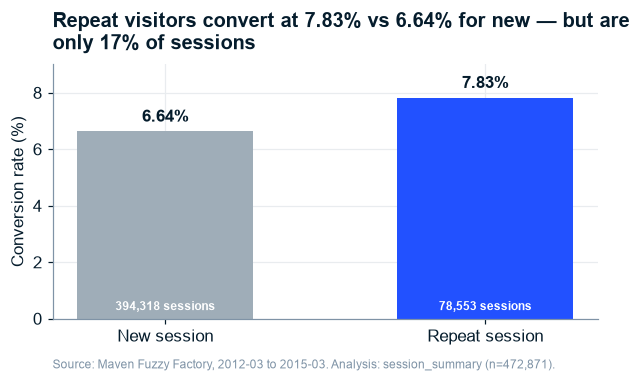

In [5]:
d = conv_by("is_repeat_session")
d.index = ["New session" if not i else "Repeat session" for i in d.index]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
colors = mck_style.highlight_colors(d.index, winner="Repeat session")
ax.bar(d.index, d["conv_pct"], color=colors, width=0.55)
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=4, fontweight="bold")
ax.set_title("Repeat visitors convert at 7.83% vs 6.64% for new \u2014 but are\nonly 17% of sessions")
ax.set_ylabel("Conversion rate (%)")
ax.set_ylim(0, 9)
for i, (n, row) in enumerate(d.iterrows()):
    ax.annotate(f"{row['sessions']:,.0f} sessions", (i, 0.3), ha="center", color="white", fontsize=8, fontweight="bold")
viz.add_source(ax, SRC)
viz.save_exhibit(fig, "A3_new_vs_repeat"); plt.show()

**So What:** Returning visitors are the more valuable cohort but a small share of traffic. **Implication:** remarketing / return-driving programs have headroom \u2014 growing the repeat share lifts blended conversion.

---
## Part B — Conversion
*MECE branch: turn the traffic we have into orders.*

### Exhibit B1 — Only 36% of product viewers reach the cart — the funnel's weakest step

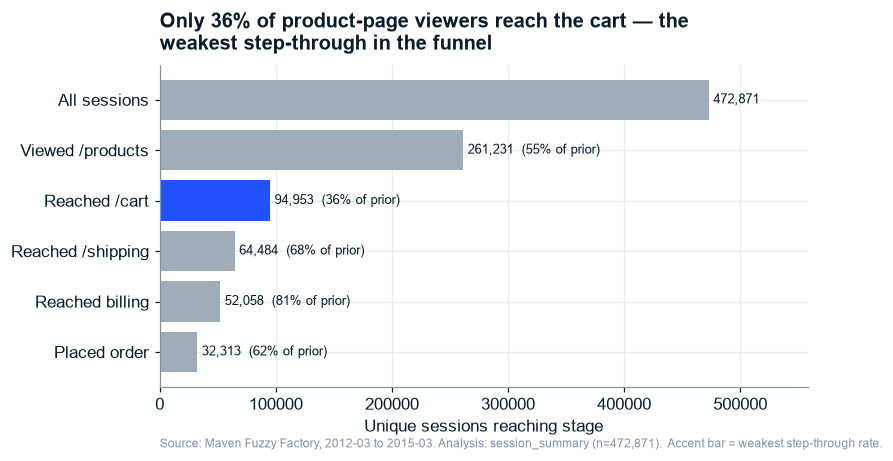

In [6]:
def reach(url_or_list):
    urls = [url_or_list] if isinstance(url_or_list, str) else url_or_list
    return pageviews.loc[pageviews["pageview_url"].isin(urls), "website_session_id"].nunique()

stages = [
    ("All sessions", N_SESSIONS),
    ("Viewed /products", reach("/products")),
    ("Reached /cart", reach("/cart")),
    ("Reached /shipping", reach("/shipping")),
    ("Reached billing", reach(["/billing", "/billing-2"])),
    ("Placed order", reach("/thank-you-for-your-order")),
]
labels = [s[0] for s in stages]
vals = [s[1] for s in stages]
step_pct = [np.nan] + [vals[i] / vals[i-1] * 100 for i in range(1, len(vals))]

fig, ax = plt.subplots(figsize=(7.6, 3.8))
worst = int(np.nanargmin(step_pct))  # weakest step-through rate = products -> cart
colors = [mck_style.ACCENT if i == worst else mck_style.CONTEXT for i in range(len(vals))]
ax.barh(range(len(vals)), vals, color=colors)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(labels)
ax.invert_yaxis()
for i, v in enumerate(vals):
    step = "" if i == 0 else f"  ({step_pct[i]:.0f}% of prior)"
    ax.annotate(f"{v:,.0f}{step}", (v + 4000, i), va="center", fontsize=8.5, color=mck_style.NAVY)
ax.set_title("Only 36% of product-page viewers reach the cart — the\nweakest step-through in the funnel")
ax.set_xlabel("Unique sessions reaching stage"); ax.set_xlim(0, N_SESSIONS * 1.18)
viz.add_source(ax, SRC + "  Accent bar = weakest step-through rate.")
viz.save_exhibit(fig, "B1_funnel"); plt.show()

**So What:** Two steps leak most. In *absolute* terms **landing → products** loses the most sessions (211k of 473k never leave the landing page); in *rate* terms **products → cart** is the weakest (only 36% of product viewers add to cart). Once users reach the cart, checkout completion is comparatively strong (62–81% per step). **Implication:** the landing page and the product-page → cart transition are the two highest-leverage on-site fixes — the landing-page split test in B2 addresses the first directly.

### Exhibit B2 — Landing-page test: /lander-5 converts 44% better than /home

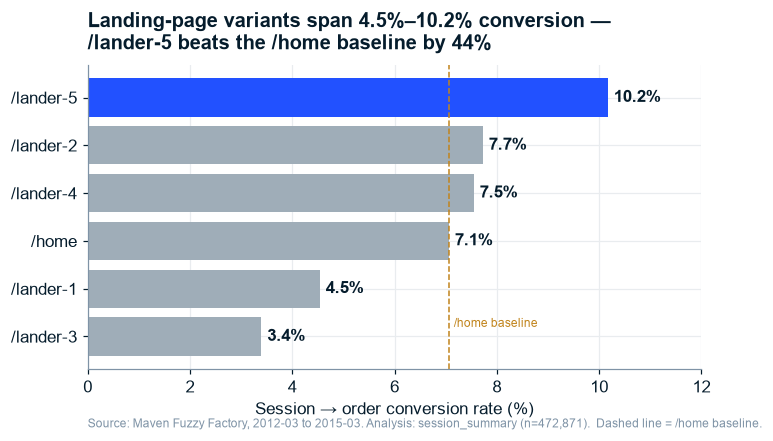

In [7]:
landers = ["/home", "/lander-1", "/lander-2", "/lander-3", "/lander-4", "/lander-5"]
d = conv_by("entry_url", source=ss[ss["entry_url"].isin(landers)]).reindex(landers).dropna()
d = d.sort_values("conv_pct")
fig, ax = plt.subplots(figsize=(7.2, 3.6))
colors = mck_style.highlight_colors(d.index, winner="/lander-5")
ax.barh(d.index, d["conv_pct"], color=colors)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=4, fontweight="bold")
ax.axvline(d.loc["/home", "conv_pct"], color=mck_style.REFERENCE, ls="--", lw=1)
ax.annotate("/home baseline", (d.loc["/home", "conv_pct"] + 0.1, 0.2), color=mck_style.REFERENCE, fontsize=8)
ax.set_title("Landing-page variants span 4.5%\u201310.2% conversion \u2014\n/lander-5 beats the /home baseline by 44%")
ax.set_xlabel("Session \u2192 order conversion rate (%)"); ax.set_xlim(0, 12)
viz.add_source(ax, SRC + "  Dashed line = /home baseline.")
viz.save_exhibit(fig, "B2_landing_pages"); plt.show()

**So What:** Landing-page experience swings conversion by more than 2x (4.5% to 10.2%). `/lander-5` is the standout; `/lander-1` and `/lander-3` materially underperform `/home`. **Implication (Path C candidate):** this is a genuine intervention \u2014 routing traffic to the best lander could lift conversion, but the causal read (were variants tested on comparable traffic and periods?) must be confirmed in Stage 5, not assumed here.

### Exhibit B3 — Conversion nearly tripled over three years

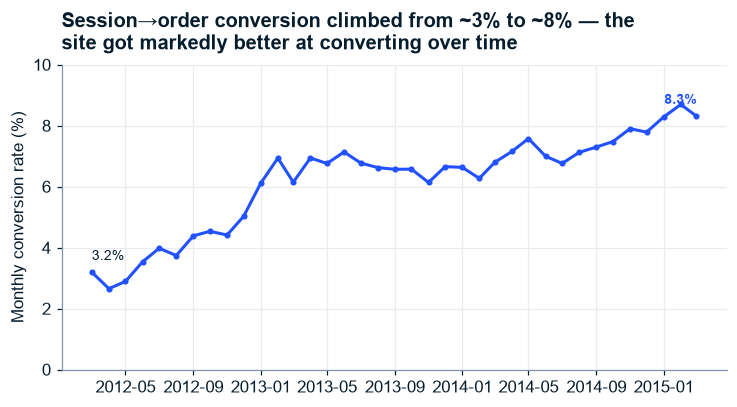

In [8]:
ss["month"] = ss["session_start"].dt.to_period("M").dt.to_timestamp()
mt = ss.groupby("month").agg(sessions=("is_converted", "size"), conv=("is_converted", "mean"))
mt["conv_pct"] = mt["conv"] * 100
fig, ax = plt.subplots(figsize=(7.8, 3.6))
ax.plot(mt.index, mt["conv_pct"], color=mck_style.ACCENT, lw=2, marker="o", ms=3)
ax.set_title("Session\u2192order conversion climbed from ~3% to ~8% \u2014 the\nsite got markedly better at converting over time")
ax.set_ylabel("Monthly conversion rate (%)"); ax.set_ylim(0, 10)
ax.annotate(f"{mt['conv_pct'].iloc[0]:.1f}%", (mt.index[0], mt['conv_pct'].iloc[0] + 0.4), color=mck_style.NAVY, fontsize=9)
ax.annotate(f"{mt['conv_pct'].iloc[-1]:.1f}%", (mt.index[-1], mt['conv_pct'].iloc[-1] + 0.4), color=mck_style.ACCENT, fontsize=9, fontweight="bold", ha="right")
viz.add_source(ax, SRC)
viz.save_exhibit(fig, "B3_conversion_trend"); plt.show()

**So What:** Conversion improved steadily, consistent with the landing-page and checkout iterations landing over time. **Implication:** whatever the team changed is working \u2014 quantify which changes drove it (ties to B2) and keep iterating.

---
## Part C — Monetization
*MECE branch: grow value per order.*

### Exhibit C1 — Mr. Fuzzy drives 60% of revenue but carries the lowest margin

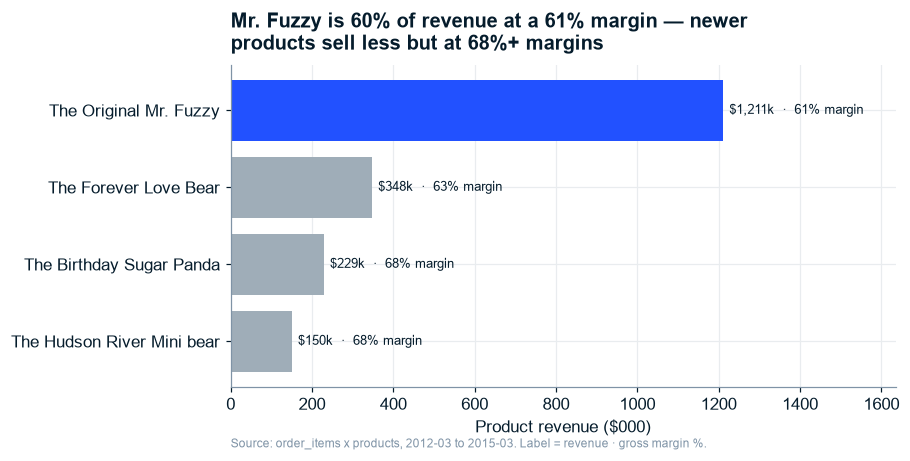

In [9]:
oi2 = order_items.merge(products[["product_id", "product_name"]], on="product_id", how="left")
d = (oi2.groupby("product_name")
     .agg(revenue=("price_usd", "sum"), margin=("margin_usd", "sum"))
     .assign(margin_pct=lambda x: x["margin"] / x["revenue"] * 100)
     .sort_values("revenue"))
fig, ax = plt.subplots(figsize=(7.8, 3.8))
colors = mck_style.highlight_colors(d.index, winner="The Original Mr. Fuzzy")
ax.barh(d.index, d["revenue"] / 1000, color=colors)
for i, (n, row) in enumerate(d.iterrows()):
    ax.annotate(f"${row['revenue']/1000:,.0f}k  \u00b7  {row['margin_pct']:.0f}% margin", (row['revenue']/1000 + 15, i), va="center", fontsize=8.5, color=mck_style.NAVY)
ax.set_title("Mr. Fuzzy is 60% of revenue at a 61% margin \u2014 newer\nproducts sell less but at 68%+ margins")
ax.set_xlabel("Product revenue ($000)"); ax.set_xlim(0, d["revenue"].max()/1000 * 1.35)
viz.add_source(ax, "Source: order_items x products, 2012-03 to 2015-03. Label = revenue \u00b7 gross margin %.")
viz.save_exhibit(fig, "C1_product_revenue_margin"); plt.show()

**So What:** Revenue is highly concentrated in the flagship, which is also the *lowest-margin* product; the three newer toys are smaller but 7\u20138 margin points richer. **Implication:** portfolio dependence on one aging, lower-margin SKU is a risk \u2014 growing the higher-margin newer products (and cross-selling them) improves blended profitability.

### Exhibit C2 — Cross-sell went from 0% to 34% of orders, lifting AOV ~$50 to ~$63

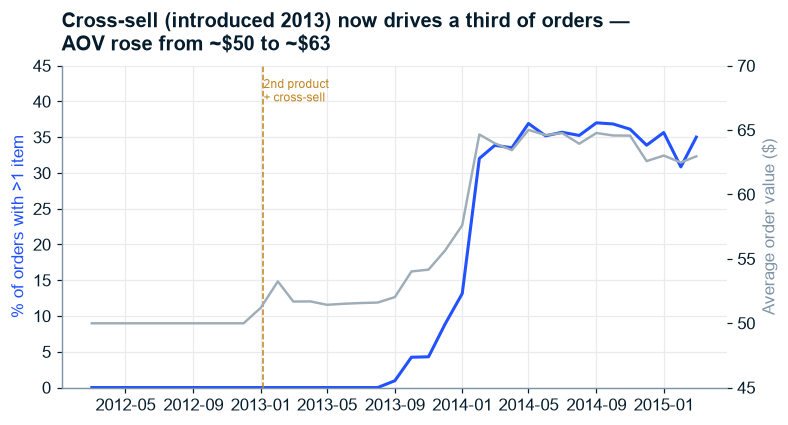

In [10]:
orders["month"] = orders["created_at"].dt.to_period("M").dt.to_timestamp()
m = orders.groupby("month").agg(multi=("items_purchased", lambda x: (x > 1).mean() * 100), aov=("price_usd", "mean"))
fig, ax = plt.subplots(figsize=(7.8, 3.8))
ax.plot(m.index, m["multi"], color=mck_style.ACCENT, lw=2, label="% multi-item orders")
ax.set_ylabel("% of orders with >1 item", color=mck_style.ACCENT); ax.set_ylim(0, 45)
launch = pd.Timestamp("2013-01-06")  # 2nd product (Forever Love Bear)
ax.axvline(launch, color=mck_style.REFERENCE, ls="--", lw=1)
ax.annotate("2nd product\n+ cross-sell", (launch, 40), color=mck_style.REFERENCE, fontsize=8, ha="left")
ax2 = ax.twinx(); ax2.plot(m.index, m["aov"], color=mck_style.GREY, lw=1.6, label="AOV ($)"); ax2.grid(False)
ax2.set_ylabel("Average order value ($)", color=mck_style.SLATE); ax2.set_ylim(45, 70)
ax.set_title("Cross-sell (introduced 2013) now drives a third of orders \u2014\nAOV rose from ~$50 to ~$63")
viz.add_source(ax, "Source: orders, 2012-03 to 2015-03. Blue = % multi-item (left); grey = AOV (right).")
viz.save_exhibit(fig, "C2_crosssell_aov"); plt.show()

**So What:** Cross-sell is a proven AOV lever \u2014 essentially nil before 2013, now ~34% of orders, with AOV up ~25%. **Implication:** the cross-sell mechanic works; extending it (more/better recommended add-ons, especially the higher-margin newer products) is a direct margin lever. *Note: structural time confound \u2014 cross-sell only became possible once a 2nd product existed.*

---
## Part D — Leakage
*MECE branch: stop value leaking back out.*

### Exhibit D1 — Refund rates vary 5x by product; Sugar Panda is the worst

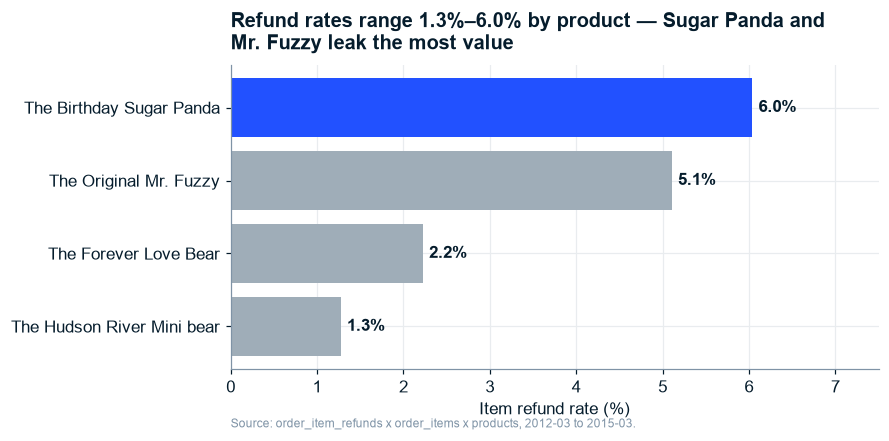

In [11]:
units = oi2.groupby("product_name").size().rename("units")
ri = refunds.merge(order_items[["order_item_id", "product_id"]], on="order_item_id", how="left") \
            .merge(products[["product_id", "product_name"]], on="product_id", how="left")
refs = ri.groupby("product_name").size().rename("refunds")
d = pd.concat([units, refs], axis=1).fillna(0)
d["rate"] = d["refunds"] / d["units"] * 100
d = d.sort_values("rate")
fig, ax = plt.subplots(figsize=(7.6, 3.6))
colors = mck_style.highlight_colors(d.index, winner="The Birthday Sugar Panda")
ax.barh(d.index, d["rate"], color=colors)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=4, fontweight="bold")
ax.set_title("Refund rates range 1.3%\u20136.0% by product \u2014 Sugar Panda and\nMr. Fuzzy leak the most value")
ax.set_xlabel("Item refund rate (%)"); ax.set_xlim(0, 7.5)
viz.add_source(ax, "Source: order_item_refunds x order_items x products, 2012-03 to 2015-03.")
viz.save_exhibit(fig, "D1_refund_by_product"); plt.show()

**So What:** Refund exposure is concentrated: Sugar Panda (6.0%) and the high-volume Mr. Fuzzy (5.1%) drive most refunded value, while the two other products are under 2.3%. **Implication:** a product-quality/QA review of the two worst offenders would protect margin \u2014 but *no refund-reason field exists*, so this flags where to investigate, not why.

### Exhibit D2 — Refund rate peaked at 9% in 2012 and has since halved

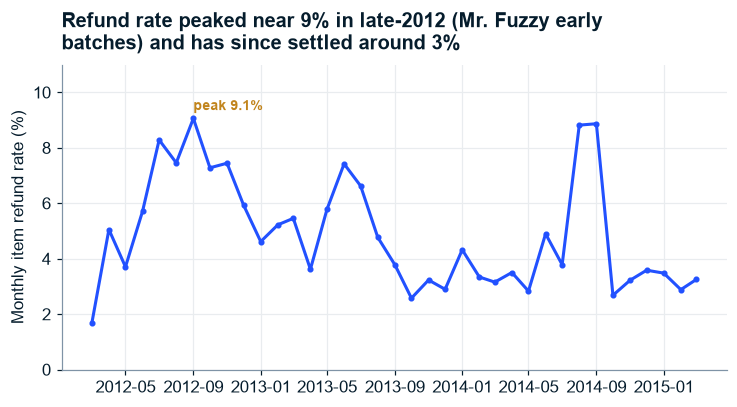

In [12]:
order_items["month"] = order_items["created_at"].dt.to_period("M").dt.to_timestamp()
items_m = order_items.groupby("month").size().rename("items")
ref_m = refunds.merge(order_items[["order_item_id", "month"]], on="order_item_id", how="left").groupby("month").size().rename("refunds")
d = pd.concat([items_m, ref_m], axis=1).fillna(0)
d["rate"] = d["refunds"] / d["items"] * 100
fig, ax = plt.subplots(figsize=(7.8, 3.6))
ax.plot(d.index, d["rate"], color=mck_style.ACCENT, lw=2, marker="o", ms=3)
peak = d["rate"].idxmax()
ax.annotate(f"peak {d['rate'].max():.1f}%", (peak, d["rate"].max() + 0.3), color=mck_style.REFERENCE, fontsize=9, fontweight="bold")
ax.set_title("Refund rate peaked near 9% in late-2012 (Mr. Fuzzy early\nbatches) and has since settled around 3%")
ax.set_ylabel("Monthly item refund rate (%)"); ax.set_ylim(0, 11)
viz.add_source(ax, "Source: order_item_refunds vs order_items by item purchase month.")
viz.save_exhibit(fig, "D2_refund_trend"); plt.show()

**So What:** The early refund spike looks like a first-product quality issue that was resolved; the trend is healthy. **Implication:** leakage is *not* currently the top priority \u2014 monitor it, but Acquisition/Conversion carry more upside.

---
## Findings summary & ghost-deck update

Revised key lines after seeing the data (feeds Stage 7):

| Branch | Finding (quantified) | So What / lever |
|---|---|---|
| **A. Acquisition** | Desktop 8.5% vs **mobile 3.1%** conversion; mobile = 31% of traffic | Mobile experience is the biggest single conversion gap |
| **A. Acquisition** | socialbook 3.2% vs 6.7–7.5% elsewhere | Reallocate/repair weakest paid source (no spend data → quality not ROI) |
| **B. Conversion** | Weakest step products→cart (36%); landing→products loses most sessions; **/lander-5 10.2% vs /home 7.1%** | Landing page & product→cart are the top on-site levers → **Path C candidate** |
| **B. Conversion** | Conversion ~3% → ~8% over 3 years | Iteration is working; keep going |
| **C. Monetization** | Mr. Fuzzy = 60% of revenue at lowest (61%) margin | Portfolio concentration risk; grow higher-margin newer SKUs |
| **C. Monetization** | Cross-sell 0% → 34% of orders; AOV $50 → $63 | Proven AOV lever; extend it |
| **D. Leakage** | Refunds 9% (2012) → ~3%; Sugar Panda worst at 6% | Resolved trend; monitor, not top priority |

**Provisional Governing Thought:** *Growth is concentrated on-site — the mobile/landing-page conversion gap and cross-sell of higher-margin newer products are the highest-value levers; acquisition spend and refunds are secondary.*

### Stage 3 gate — status

| Gate item | Status |
|---|---|
| Each Stage-0 hypothesis has ≥1 analysis | ✅ A/B/C/D all covered |
| Key distributions/relationships visualised & annotated | ✅ 10 exhibits, each with So What |
| All chart titles are **action titles** | ✅ titles state the insight |
| Every finding has a So What / Implication | ✅ |
| Ghost deck updated from actual data | ✅ table above |
| Data issues logged → loop to Stage 2 | ✅ none new (data clean); caveats noted (no spend, no refund reason) |

**Next:** [Stage 5a — Statistical Testing](../DOCS/IMPLEMENTATION_PLAN.md) to confirm the conversion gaps (device, landing page) with two-proportion tests + effect sizes, and decide whether the landing-page finding is promoted to **Path C**.